# MCA - Multiple Correspondence Analysis : detect profiles in the population



ACM : Analyse factorielle des correspondances multiples



!!! Compléter les références !!!


In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
import sqlite3 as sql

In [98]:
from fanalysis.ca import CA 
from fanalysis.mca import MCA

In [99]:
### Importer un module de fonctions crées ad hoc
##  ATTENTION : le fichier 'sparql_functions.py' doit se trouver 
#   dans un dossier qui se situe dans le chemin ('path') de recherche
#   vu par le présent carnet Jupyter afin que
#   l'importation fonctionne correctement

import sys
from importlib import reload


# Add parent directory to the path
sys.path.insert(0, '..')

### If you want to add the parent-parent directory,
sys.path.insert(0, '../..')



In [100]:

import bivariate_library as bl
import correspondence_analysis_library as cal
import cluster_functions as cf


In [101]:
### Use this pnéy to reload the functions if modified
# print(reload(bl))
# print(reload(cal))  

## Import the data and prepare the analysis

In this notebook, we use the data produced with the [bivariate analysis notebook using countries](da3-1_countries_bivariate_analysis.ipynb) and the data collected in the [da5-employer.md](../../documentation/wikidata/data-analysis/da5-employer.md) and [da5-employer.sql](../../documentation/wikidata/data-analysis/da5-employer.sql) files.



In [103]:
csv_address='da_data/da4-AFC.csv'
df_p = pd.read_csv(csv_address)
df_p.head(3)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity
0,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,POINT (6.578611 46.060278),http://www.wikidata.org/entity/Q654153,1781-1790,22,Western Europe,FR,France,France,FRA,France,1831,1826-1850
1,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,POINT (11.076389 51.464722),http://www.wikidata.org/entity/Q699082,1781-1790,22,Western Europe,DE,Deutschland,Germany,DEU,Germany,1827,1826-1850
2,http://www.wikidata.org/entity/Q874465,József Csorba,1789,male,Vynohradiv,POINT (23.033056 48.139722),http://www.wikidata.org/entity/Q752334,1781-1790,8,Eastern Europe,UA,Україна,Ukraine,UKR,Ukraine,1834,1826-1850


In [104]:
df_p = df_p.drop(['CNTR_ID', 'CNTR_NAME', 'ISO3_CODE', 'activityYear', 'uriPlace', 'periods', 'FID', 'CNTR_ID'], axis=1)

In [105]:
### Inspect the dataframe and 
# notably if there are missing values
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20043 entries, 0 to 20042
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   uriPer           20043 non-null  object
 1   labelPer         20043 non-null  object
 2   birthYear        20043 non-null  int64 
 3   gender           20043 non-null  object
 4   labelPlace       20043 non-null  object
 5   geometry         20043 non-null  object
 6   REGION           20043 non-null  object
 7   NAME_ENGL        20043 non-null  object
 8   coded_country    20043 non-null  object
 9   periodsActivity  20043 non-null  object
dtypes: int64(1), object(9)
memory usage: 1.5+ MB


In [106]:
df_p=df_p.rename(columns={'uriPer': 'person_uri'})

In [107]:
df_p.head(2)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,REGION,NAME_ENGL,coded_country,periodsActivity
0,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,POINT (6.578611 46.060278),Western Europe,France,France,1826-1850
1,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,POINT (11.076389 51.464722),Western Europe,Germany,Germany,1826-1850


In [8]:
pd.set_option('display.max_columns', None)
# Reset to default settings if needed later
# pd.reset_option('display.max_columns')

In [109]:
### Import the new qualitative values to be added: occupation and employer class
csv_address='da_data/da5-persons-features.csv'
# Explicitly tell pandas which strings to treat as NA (exclude 'NA' from the list)
# By default, pandas treats 'NA', 'N/A', 'NaN', etc. as missing values.
# If you want to override this by specifying a custom list that does NOT include 'NA'.
## df_pfeat = pd.read_csv(csv_address, na_values=['', 'N/A', 'NULL', 'None'])
df_pfeat = pd.read_csv(csv_address)
df_pfeat.head()

,pk_person_features,person_uri,occupation_main,occupation_sec1,coded_employer
0,2,http://www.wikidata.org/entity/Q1000934,physicist,university-teacher,education
1,3,http://www.wikidata.org/entity/Q100153910,physicist,university-teacher,education
2,5,http://www.wikidata.org/entity/Q100157315,physicist,university-teacher,university
3,8,http://www.wikidata.org/entity/Q100212,physicist,university-teacher,publisher
4,9,http://www.wikidata.org/entity/Q100216,physicist,university-teacher,institute


In [110]:
### Observe the 
df_pfeat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10900 entries, 0 to 10899
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   pk_person_features  10900 non-null  int64 
 1   person_uri          10900 non-null  object
 2   occupation_main     10900 non-null  object
 3   occupation_sec1     10900 non-null  object
 4   coded_employer      10900 non-null  object
dtypes: int64(1), object(4)
memory usage: 425.9+ KB


In [111]:
## Merge the two dataframes
df_pm = pd.merge(df_p,df_pfeat, on='person_uri')  
# following part was used for inspection
# , how='left')

In [112]:
## The small number depends on the considered countries
df_pm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7946 entries, 0 to 7945
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   person_uri          7946 non-null   object
 1   labelPer            7946 non-null   object
 2   birthYear           7946 non-null   int64 
 3   gender              7946 non-null   object
 4   labelPlace          7946 non-null   object
 5   geometry            7946 non-null   object
 6   REGION              7946 non-null   object
 7   NAME_ENGL           7946 non-null   object
 8   coded_country       7946 non-null   object
 9   periodsActivity     7946 non-null   object
 10  pk_person_features  7946 non-null   int64 
 11  occupation_main     7946 non-null   object
 12  occupation_sec1     7946 non-null   object
 13  coded_employer      7946 non-null   object
dtypes: int64(2), object(12)
memory usage: 869.2+ KB


### Manage secondary occupation

We will have to code a part of the categories because their number is too small, which makes the variable too sparse.

In [113]:
### Group and count: secondary occupation
# We observe some dispersion that requires grouping the categories of the variable
df_count = df_pm.groupby('occupation_sec1').size()
df_count = pd.DataFrame(df_count.sort_values(ascending = False))
df_count.columns=['number']
print(len(df_count))
print(df_count.iloc[:50])



244
                          number
occupation_sec1                 
university-teacher          4947
mathematician                413
researcher                   394
astrophysicist               251
engineer                     224
nuclear-physicist            193
chemist                      166
theoretical-physicist        113
politician                   109
writer                        87
professor                     84
scientist                     54
teacher                       51
inventor                      50
meteorologist                 43
academic                      37
computer-scientist            31
biophysicist                  24
philosopher                   23
electrical-engineer           22
geophysicist                  20
discoverer-of-asteroids       16
photographer                  15
physician                     15
non-fiction-writer            14
translator                    13
historian-of-science          13
pedagogue                     12
scienc

In [115]:
## We only take the first 19 elements in the list, the more interesting ones
ldf = df_count[df_count.number > 19].index.to_list()
print(ldf)

['university-teacher', 'mathematician', 'researcher', 'astrophysicist', 'engineer', 'nuclear-physicist', 'chemist', 'theoretical-physicist', 'politician', 'writer', 'professor', 'scientist', 'teacher', 'inventor', 'meteorologist', 'academic', 'computer-scientist', 'biophysicist', 'philosopher', 'electrical-engineer', 'geophysicist']


In [116]:
## prepare the function to code the data
def code_occupation_sec1(occup, ldf):

    """
    codes values according to list
    """

    if occup in ldf:
        output = occup
    else:
        output= 'other'
    return output        

In [117]:
### Code the data
df_pm.occupation_sec1 = df_pm.occupation_sec1.apply(lambda x: code_occupation_sec1(x, ldf))

In [118]:
### Group and count: secondary occupation
# We observe the results of the codind
df_count = df_pm.groupby('occupation_sec1').size()
df_count = pd.DataFrame(df_count.sort_values(ascending = False))
df_count.columns=['number']
print(df_count)


                       number
occupation_sec1              
university-teacher       4947
other                     610
mathematician             413
researcher                394
astrophysicist            251
engineer                  224
nuclear-physicist         193
chemist                   166
theoretical-physicist     113
politician                109
writer                     87
professor                  84
scientist                  54
teacher                    51
inventor                   50
meteorologist              43
academic                   37
computer-scientist         31
biophysicist               24
philosopher                23
electrical-engineer        22
geophysicist               20


In [119]:
df_pm.head(3)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,REGION,NAME_ENGL,coded_country,periodsActivity,pk_person_features,occupation_main,occupation_sec1,coded_employer
0,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,POINT (6.578611 46.060278),Western Europe,France,France,1826-1850,27877,astronomer,mathematician,agency
1,http://www.wikidata.org/entity/Q4274939,Johann Ludwig Georg Meinecke,1781,male,Stadthagen,POINT (9.206944 52.324722),Western Europe,Germany,Germany,1826-1850,20217,physicist,chemist,university
2,http://www.wikidata.org/entity/Q5598801,Jonas Brag,1781,male,Göteborg City,POINT (11.965228 57.704581),Northern Europe,Sweden,Scandinavia,1826-1850,23593,astronomer,other,agency


## MCA

In [120]:
data_cat = df_pm[['gender', 'coded_country', 'occupation_sec1', 'coded_employer']]
data_cat.head(3)


,gender,coded_country,occupation_sec1,coded_employer
0,male,France,mathematician,agency
1,male,Germany,chemist,university
2,male,Scandinavia,other,agency


In [121]:
DActives=data_cat

In [122]:
# We inspect the table that will be analysed
p = DActives.shape[1]
#nombre d'observations
n = DActives.shape[0]
print('Number of variables:', p, ' -- Nomber of individuals (rows):', n)
#codage en 0/1


Number of variables: 4  -- Nomber of individuals (rows): 7946


### Complete disjunctive table 

Sometimes also referred to as a dummy variable matrix or indicator matrix.

In the context of Multiple Correspondence Analysis (MCA), this table is used to transform qualitative (categorical) variables into a quantitative format suitable for analysis. Each category of a qualitative variable becomes a separate binary column (0 or 1), indicating the absence or presence of that category for each individual.

In [127]:
## Complete disjunctive table
X = pd.get_dummies(DActives,prefix='',prefix_sep='')*1
X.head(3)

,female,male,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,China,Czechia,France,Germany,India,Italy,Japan,Poland,Russian Federation,Scandinavia,South America,Spain Port.,Switzerland,Ukraine,United Kingdom,United States Can.,academic,astrophysicist,biophysicist,chemist,computer-scientist,electrical-engineer,engineer,geophysicist,inventor,mathematician,meteorologist,nuclear-physicist,other,philosopher,politician,professor,researcher,scientist,teacher,theoretical-physicist,university-teacher,writer,GLAM,academy,agency,center,college,education,enterprise,facility,grande-école,institute,institution,laboratory,observatory,organization,other,publisher,school,university
0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [128]:
### Nombre total de modalités, toute variable confondue
M = X.shape[1]
print('Number of categories:', M)
#nombre max de facteurs
Hmax = M-p
print('Maximum number of factors:', Hmax)

Number of categories: 62
Maximum number of factors: 58


In [129]:
Xm = X.copy(deep=True)
#Total sum per row: 
Xm.loc[:,'Total'] = Xm.sum(axis=1)
#Total sum per column: 
Xm.loc['Total',:] = Xm.sum(axis=0)
Xm.tail()

,female,male,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,China,Czechia,France,Germany,India,Italy,Japan,Poland,Russian Federation,Scandinavia,South America,Spain Port.,Switzerland,Ukraine,United Kingdom,United States Can.,academic,astrophysicist,biophysicist,chemist,computer-scientist,electrical-engineer,engineer,geophysicist,inventor,mathematician,meteorologist,nuclear-physicist,other,philosopher,politician,professor,researcher,scientist,teacher,theoretical-physicist,university-teacher,writer,GLAM,academy,agency,center,college,education,enterprise,facility,grande-école,institute,institution,laboratory,observatory,organization,other,publisher,school,university,Total
7942,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0
7943,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0
7944,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
7945,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4.0
Total,577.0,7369.0,314.0,236.0,291.0,161.0,123.0,224.0,423.0,1545.0,118.0,387.0,150.0,394.0,747.0,177.0,112.0,177.0,168.0,273.0,524.0,1402.0,37.0,251.0,24.0,166.0,31.0,22.0,224.0,20.0,50.0,413.0,43.0,193.0,610.0,23.0,109.0,84.0,394.0,54.0,51.0,113.0,4947.0,87.0,53.0,30.0,215.0,12.0,40.0,2846.0,98.0,41.0,5.0,1119.0,14.0,14.0,109.0,402.0,64.0,1761.0,39.0,1084.0,31784.0


## MCA

The Complete disjoint table is created interanlly by the software

In [130]:
acm = MCA(row_labels=DActives.index,var_labels=DActives.columns)
acm.fit(DActives.values)

,n_components,None
,row_labels,"RangeIndex(st...=7946, step=1)"
,var_labels,Index(['gende...type='object')
,stats,True


In [133]:
eig = pd.DataFrame(acm.eig_).transpose()
eig.columns=['contribution','freq','freq_cumulee']

print('Number of factors (approximation tables):', len(eig), '\n')
print(eig.head(), eig.tail())


Number of factors (approximation tables): 58 

   contribution      freq  freq_cumulee
0      0.403250  2.781035      2.781035
1      0.356273  2.457055      5.238090
2      0.331084  2.283335      7.521425
3      0.320803  2.212437      9.733863
4      0.315349  2.174822     11.908684     contribution      freq  freq_cumulee
53      0.186534  1.286441     95.689152
54      0.183959  1.268682     96.957835
55      0.175481  1.210213     98.168048
56      0.160694  1.108236     99.276284
57      0.104939  0.723716    100.000000


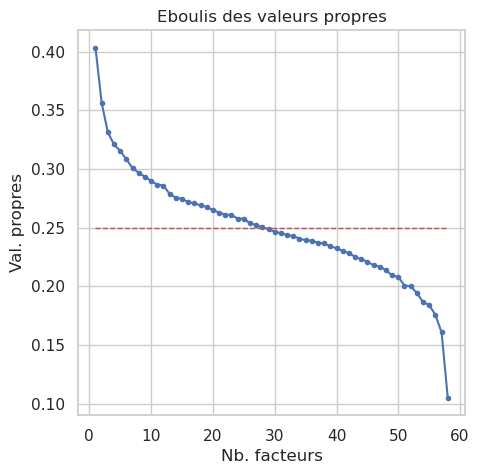

In [134]:
#éboulis des v.p.
fix,ax = plt.subplots(figsize=(5,5))
ax.plot(range(1,Hmax+1),acm.eig_[0],".-")
ax.set_xlabel("Nb. facteurs")
ax.set_ylabel("Val. propres")
plt.title("Eboulis des valeurs propres")
#seuil - Règle de Kaiser
ax.plot([1,Hmax],[1/p,1/p],"r--",linewidth=1)
plt.show()

*Diagramme d'éboulis*. Représentation graphique ayant pour but d'identifier un point d'inflexion dans une courbe de la variance. Le nom donné à ce type de graphique vient de la ressemblance de la courbe avec le profil des éboulis (scree) au bas d'une falaise. [DataFranca, Diagramme d'éboulis, 2024](https://datafranca.org/wiki/index.php?title=Diagramme_d%27%C3%A9boulis&oldid=93502)

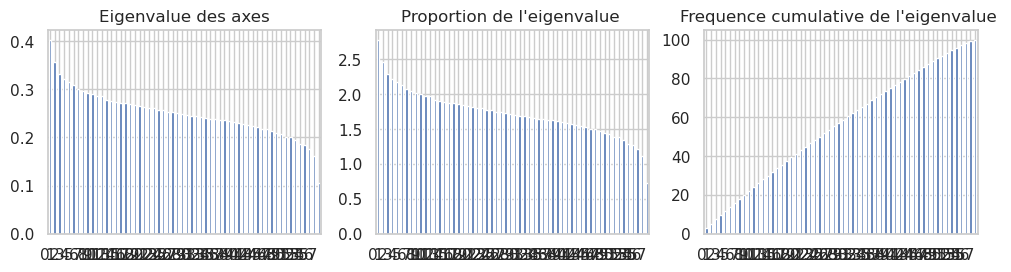

In [135]:

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12,3))

eig.iloc[:,0].plot(kind='bar', ax=axes[0], title='Eigenvalue des axes')
eig.iloc[:,1].plot(kind='bar', ax=axes[1], title="Proportion de l'eigenvalue ")
eig.iloc[:,2].plot(kind='bar', ax=axes[2], title="Frequence cumulative de l'eigenvalue ")
# Met les valeurs xticks en vertical
fig.autofmt_xdate(rotation=0)
plt.show()

<Axes: title={'center': 'Factor map for columns'}, xlabel='Dim 1 (2.78%)', ylabel='Dim 2 (2.46%)'>

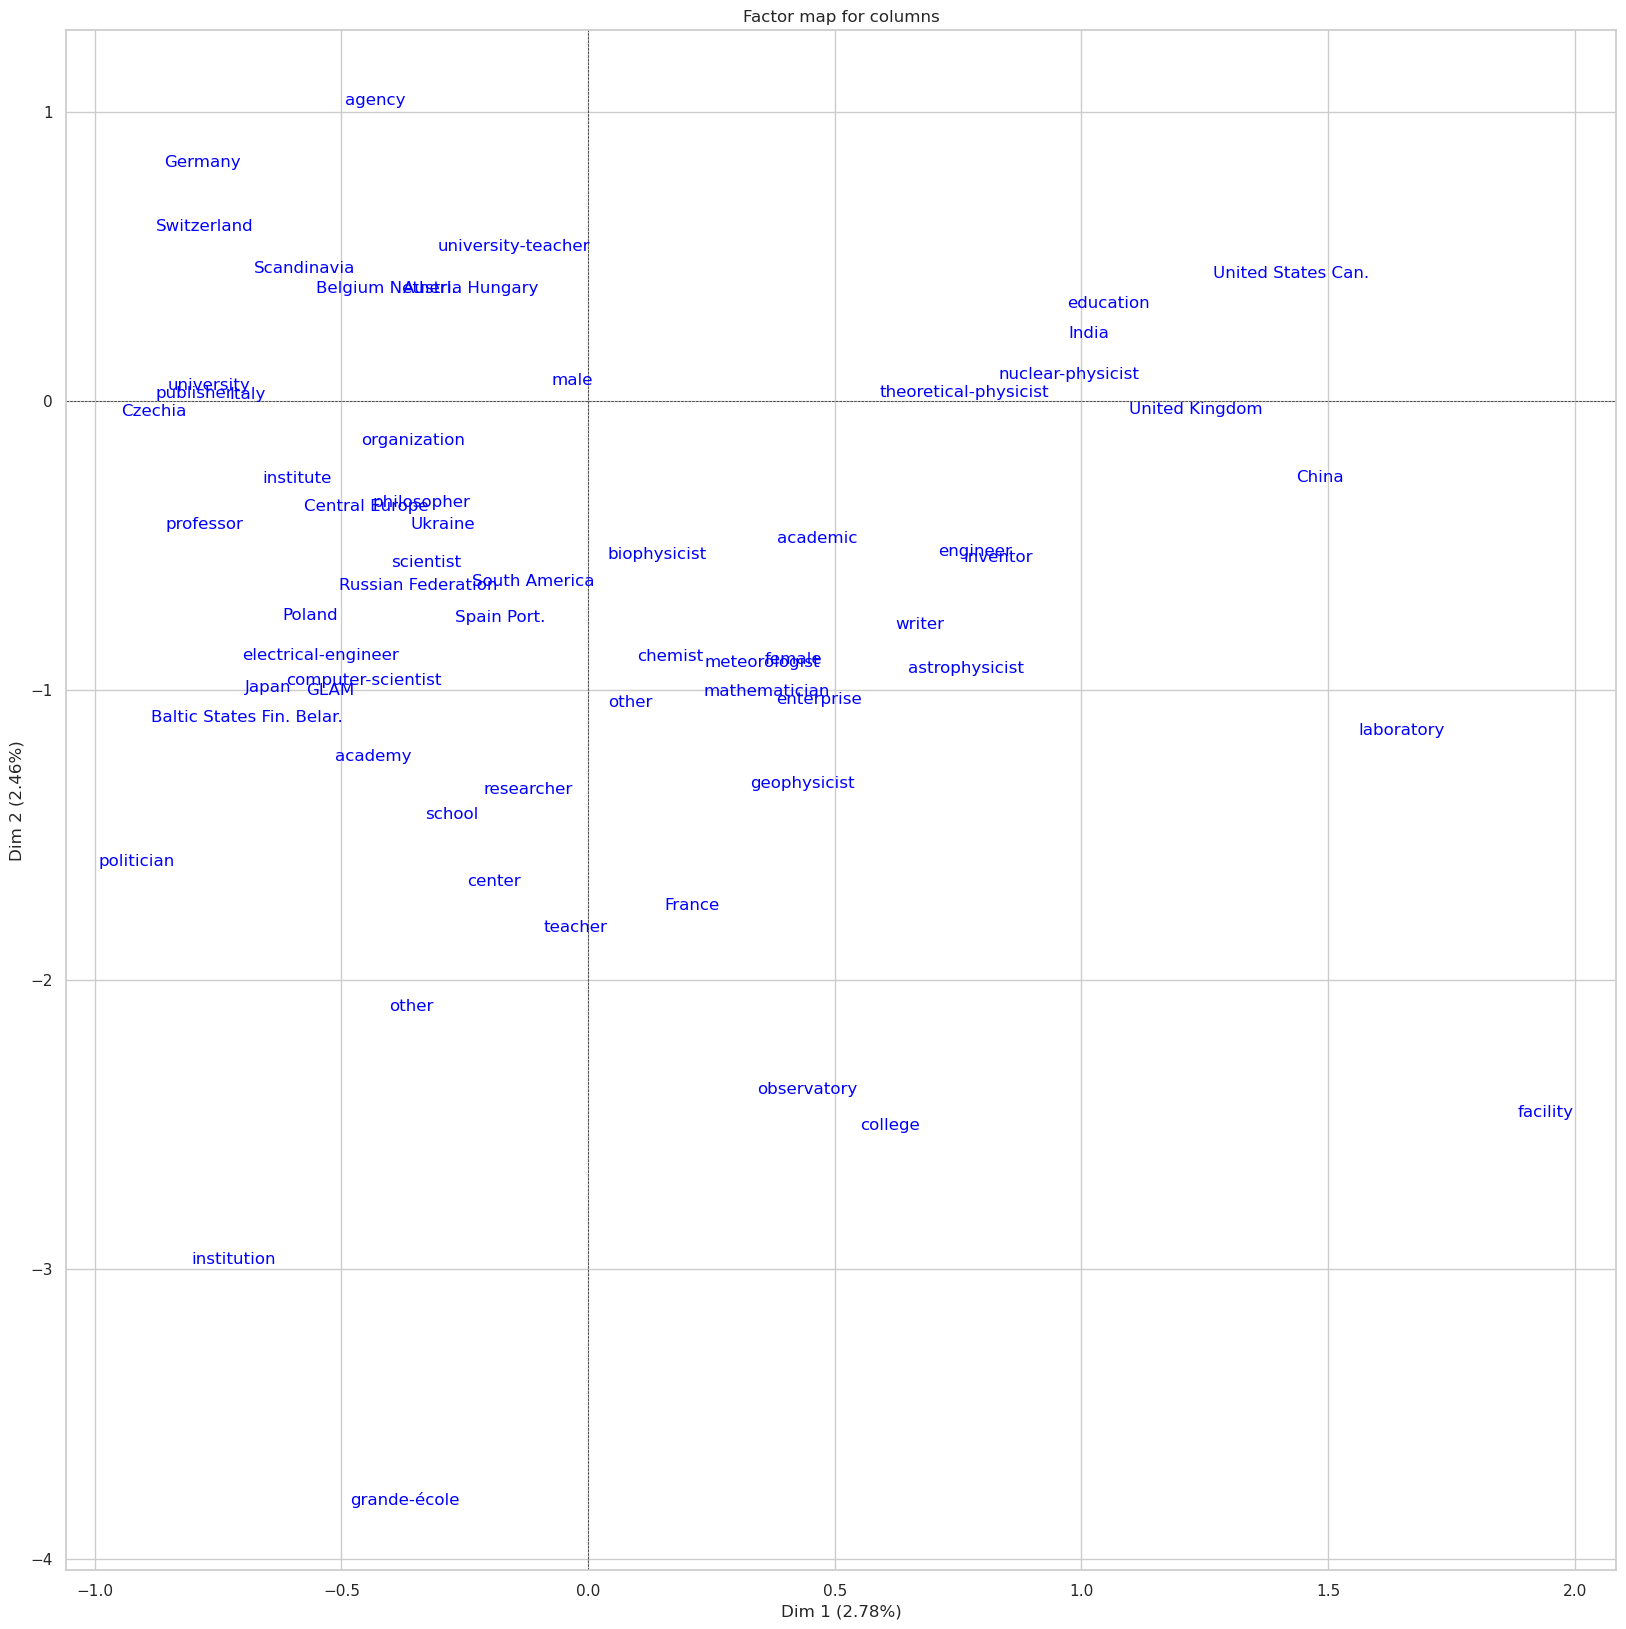

In [136]:
# Mapping des points colonnes
acm.mapping_col(num_x_axis=1, num_y_axis=2, figsize=(20,20))

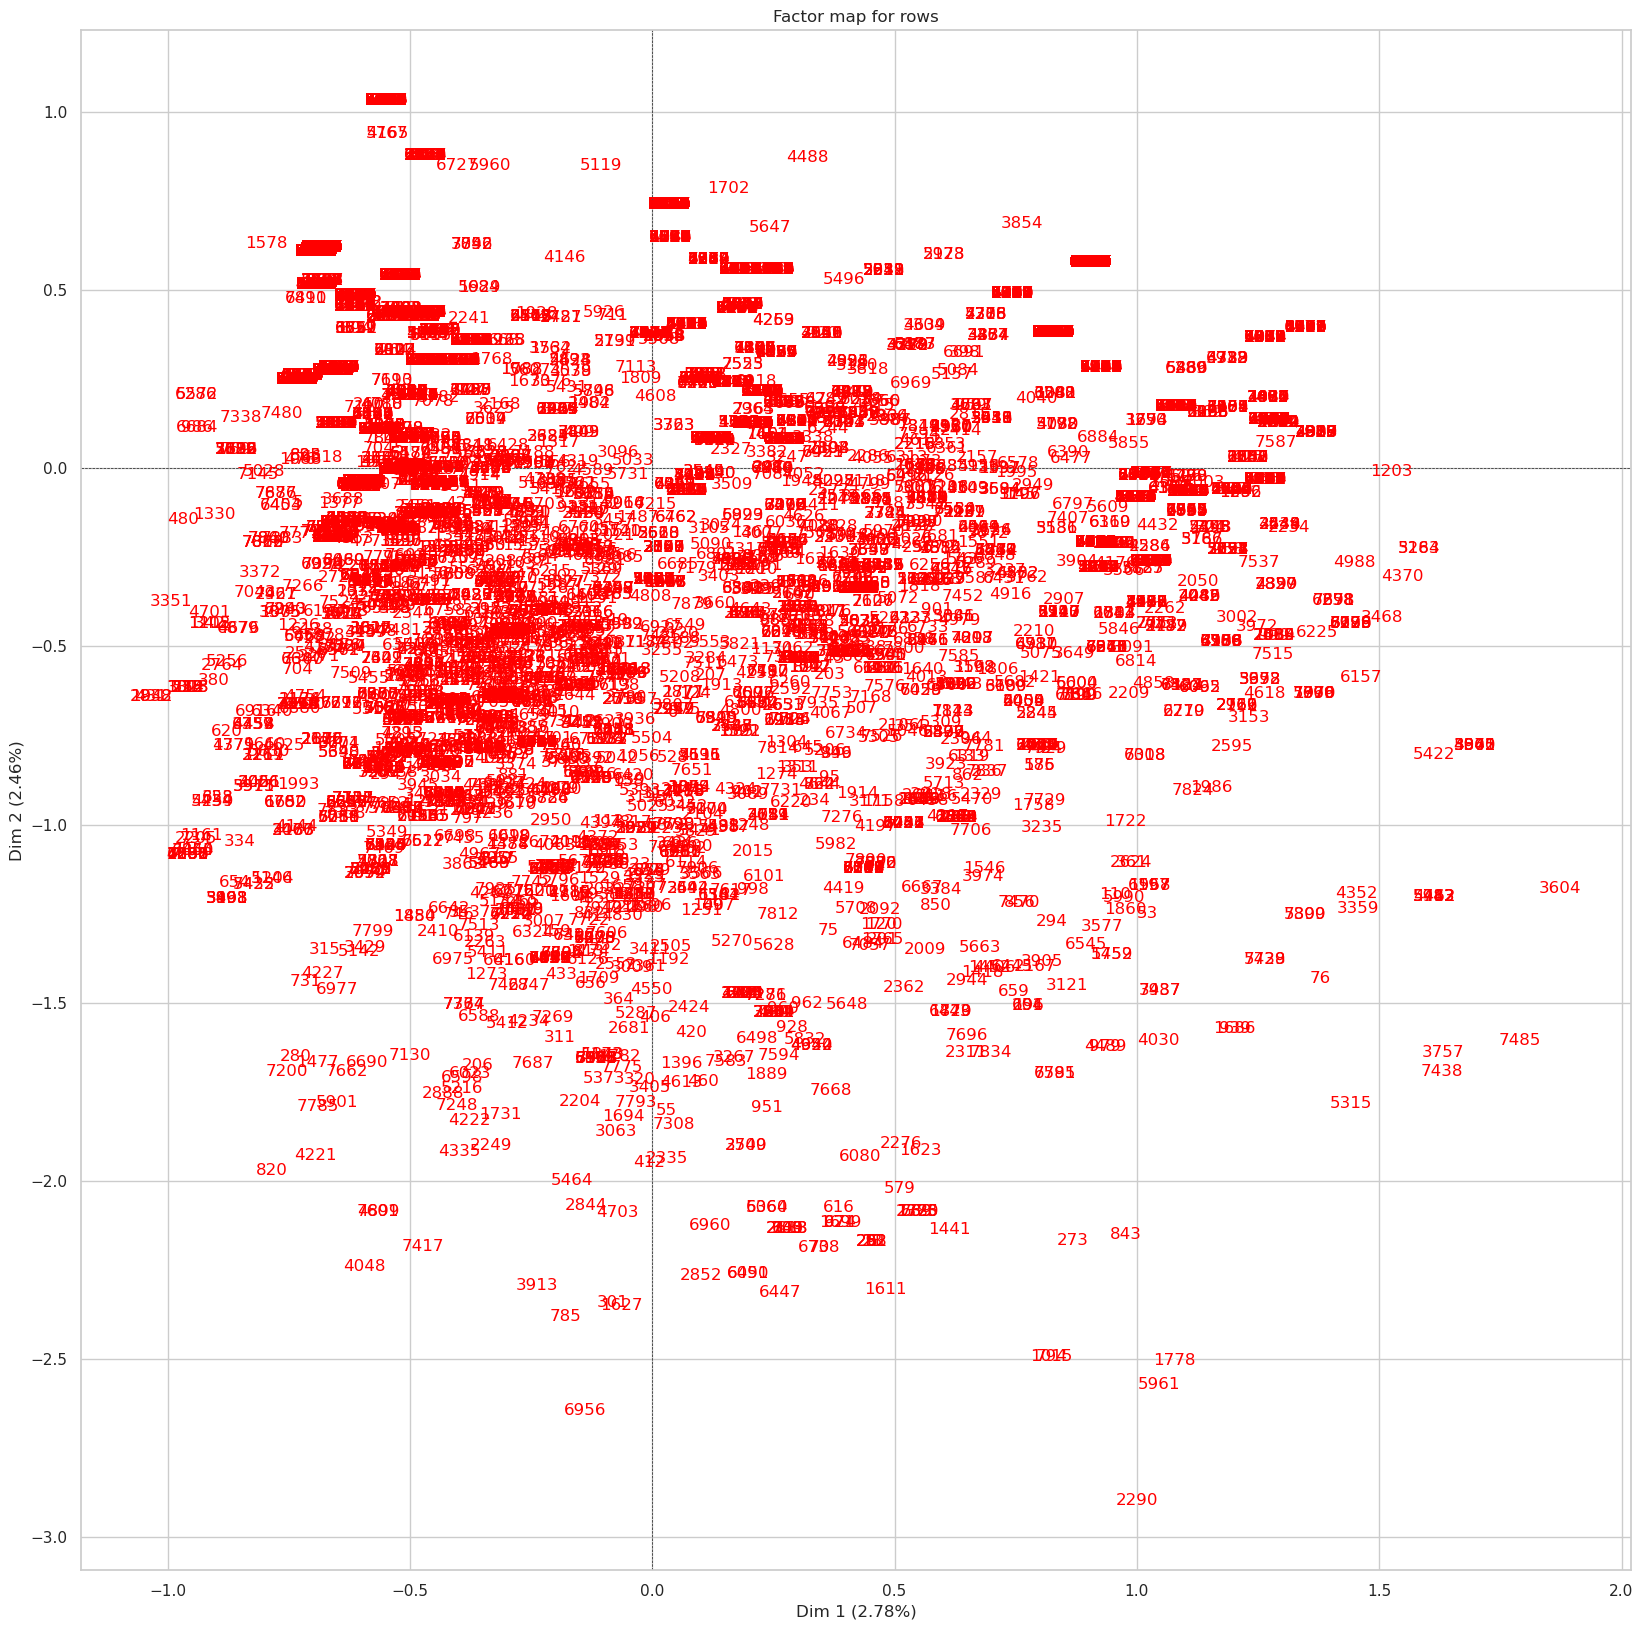

In [137]:
# Mapping des points lignes: individus
acm.mapping_row(num_x_axis=1, num_y_axis=2, figsize=(20,20))

## Représenter les individus

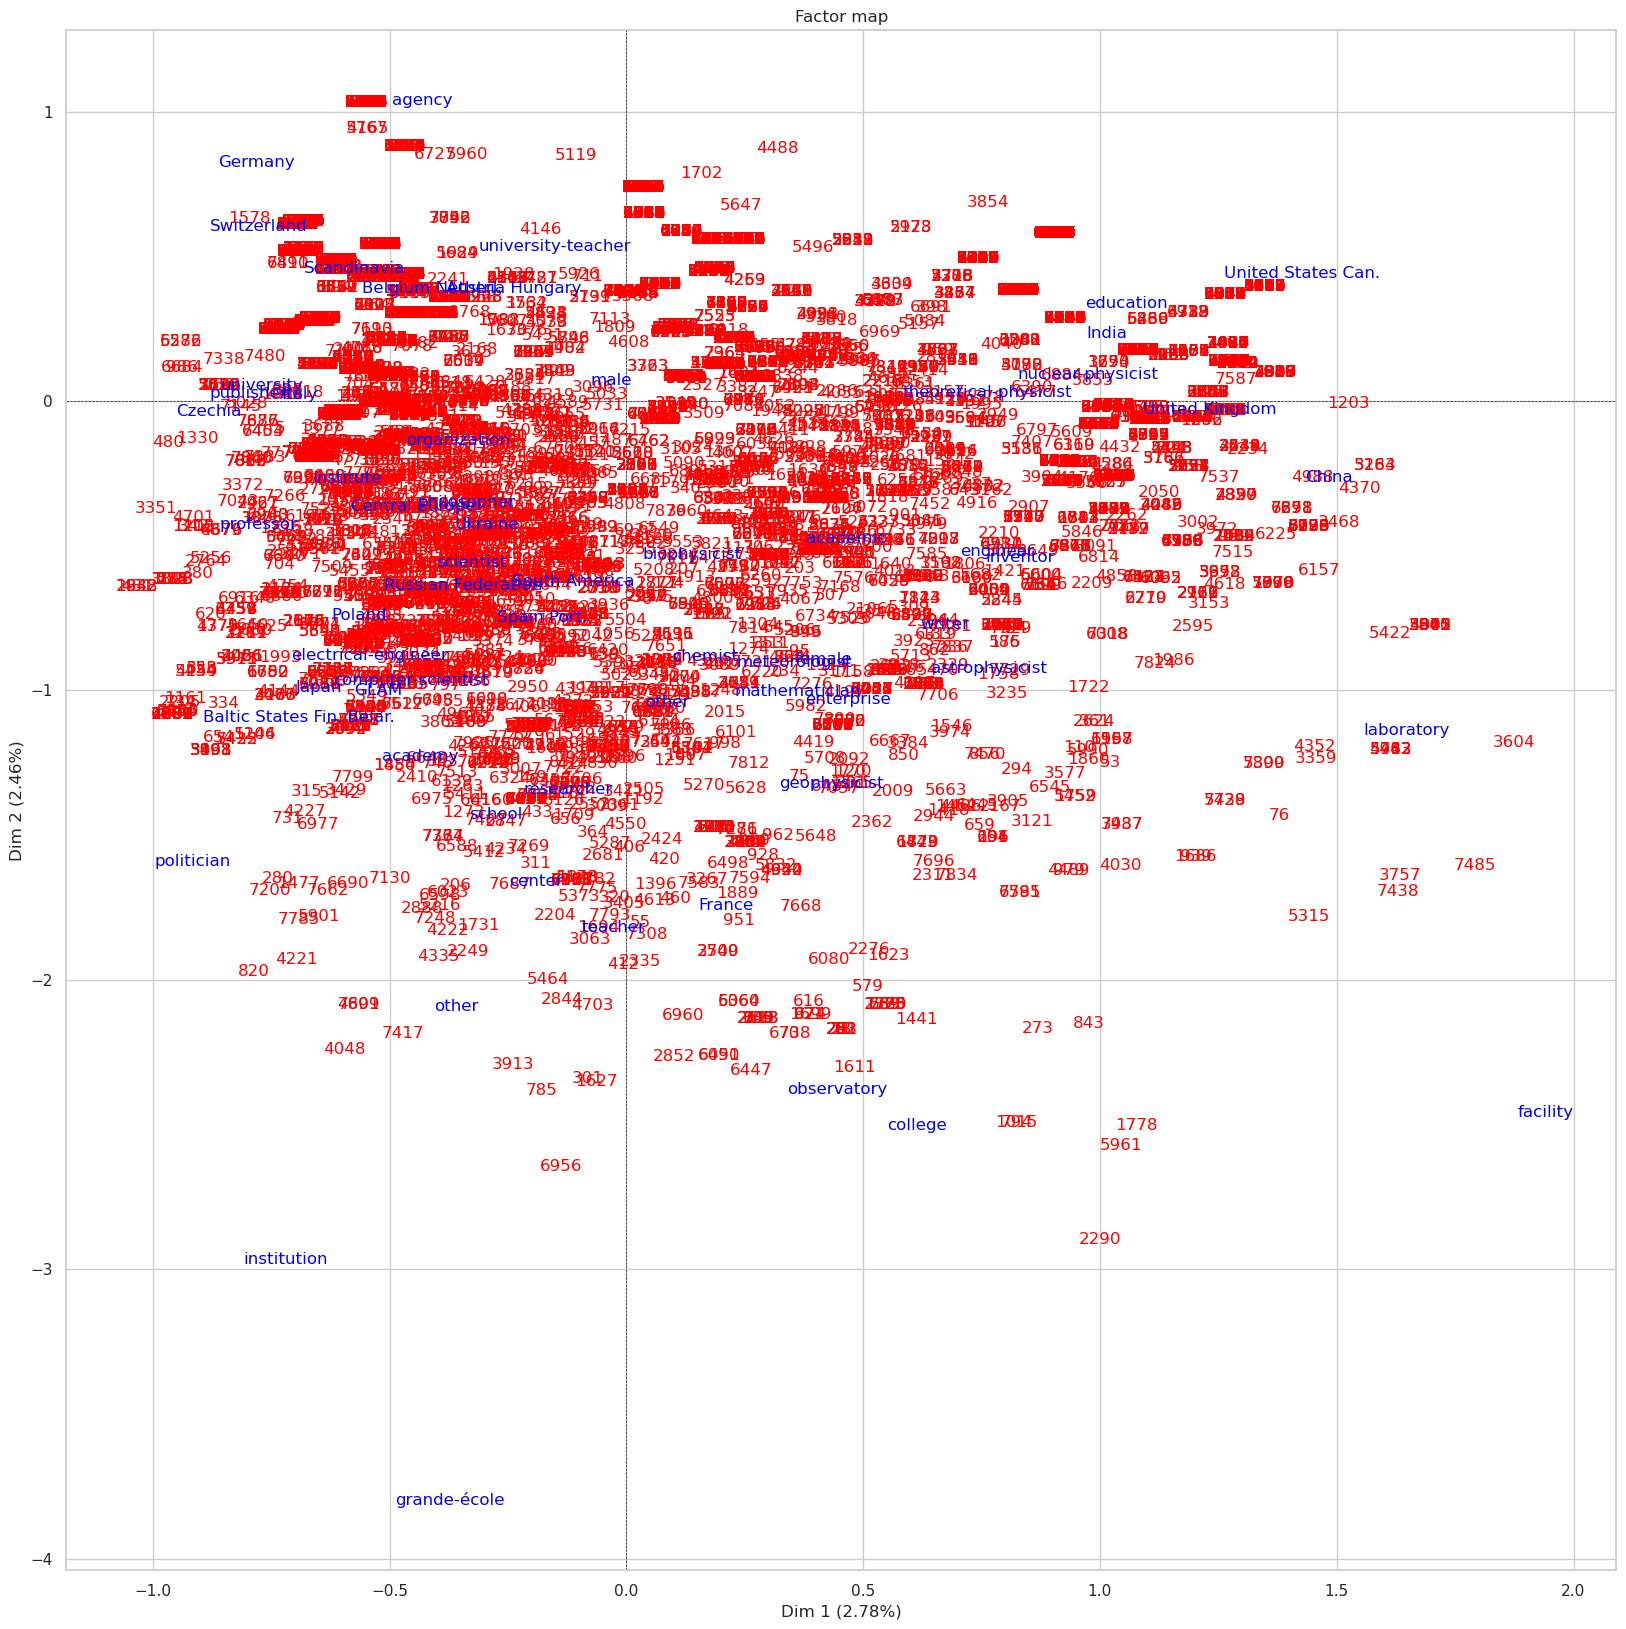

In [138]:
# Mapping simultané des points lignes et colonnes
# Les paramètres de la méthode mapping indiquent que ce sont les axes 1 et 2 qui sont ici représentés
acm.mapping(num_x_axis=1, num_y_axis=2, figsize=(20,20), )

In [144]:
### Inspect individuals
df_pm.loc[[6977, 4277, 3604, 5422, 2290]]

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,REGION,NAME_ENGL,coded_country,periodsActivity,pk_person_features,occupation_main,occupation_sec1,coded_employer
6977,http://www.wikidata.org/entity/Q55823,Janina Ochojska,1955,female,Gdańsk,POINT (18.654023 54.348291),Eastern Europe,Poland,Poland,1976-2000,23431,astronomer,politician,institute
4277,http://www.wikidata.org/entity/Q447567,James Trefil,1938,male,Chicago,POINT (-87.627778 41.881944),Northern America,United States,United States Can.,1976-2000,20775,physicist,university-teacher,education
3604,http://www.wikidata.org/entity/Q17395359,Arianna W. Rosenbluth,1927,female,Houston,POINT (-95.383056 29.762778),Northern America,United States,United States Can.,1951-1975,12288,physicist,nuclear-physicist,facility
5422,http://www.wikidata.org/entity/Q11168661,"George Chapline, Jr.",1942,male,Teaneck,POINT (-74.016111 40.8975),Northern America,United States,United States Can.,1976-2000,2345,physicist,theoretical-physicist,facility
2290,http://www.wikidata.org/entity/Q51954720,Noëlle de Leiris,1910,female,Paris,POINT (2.352222 48.856667),Western Europe,France,France,1951-1975,22302,physicist,teacher,facility


## Une possibilité d'interprétation: distance des individus par rapport au profil moyen

In [145]:
#Profil individu moyen
ind_moy = np.sum(X.values,axis=0)/(n*p)
print(ind_moy)

[1.81537881e-02 2.31846212e-01 9.87918450e-03 7.42511956e-03
 9.15554996e-03 5.06544173e-03 3.86987163e-03 7.04757110e-03
 1.33085829e-02 4.86093632e-02 3.71255978e-03 1.21759376e-02
 4.71935565e-03 1.23961742e-02 2.35023911e-02 5.56883967e-03
 3.52378555e-03 5.56883967e-03 5.28567833e-03 8.58922728e-03
 1.64862824e-02 4.41102441e-02 1.16410773e-03 7.89705512e-03
 7.55096904e-04 5.22275359e-03 9.75333501e-04 6.92172162e-04
 7.04757110e-03 6.29247420e-04 1.57311855e-03 1.29939592e-02
 1.35288195e-03 6.07223760e-03 1.91920463e-02 7.23634533e-04
 3.42939844e-03 2.64283916e-03 1.23961742e-02 1.69896803e-03
 1.60458092e-03 3.55524792e-03 1.55644349e-01 2.73722628e-03
 1.66750566e-03 9.43871130e-04 6.76440977e-03 3.77548452e-04
 1.25849484e-03 8.95419079e-02 3.08331236e-03 1.28995721e-03
 1.57311855e-04 3.52063932e-02 4.40473194e-04 4.40473194e-04
 3.42939844e-03 1.26478731e-02 2.01359174e-03 5.54052353e-02
 1.22703247e-03 3.41052102e-02]


In [146]:
### Ajouter une colonne avec la distance chi-2 de chaque individu par rapport à l'individu moyen
# pour chaque individu: les individus plus éloignés sont plus rares
X['dist_org'] = X.apply(lambda x: round(np.sum(1/ind_moy*(x/p-ind_moy)**2),4), raw=True, axis=1)
X['dist_org']

0       18.0153
1       14.3548
2       22.9888
3        7.0152
4       11.2587
         ...   
7941    11.5923
7942     5.9627
7943    27.4103
7944    10.6278
7945    13.1377
Name: dist_org, Length: 7946, dtype: float64

count    7946.000000
mean       14.499996
std        22.358417
min         1.654900
25%         3.458500
50%         8.380450
75%        15.468750
max       491.906900
Name: dist_org, dtype: float64


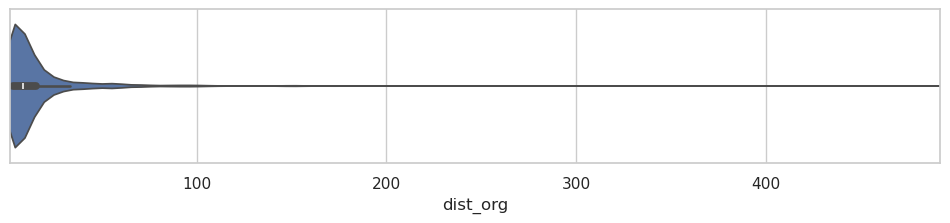

In [147]:

### Distribution des distances à l'individu moyen

sns.set_theme(style="whitegrid",rc={"figure.figsize":(12,2)} )


a = X['dist_org']

print(a.describe())

# ax = sns.boxplot(x=a)
ax = sns.violinplot(x=a)

### Noter que au delà des limites les valeurs sont coupées car postulées
ax.set_xlim(left=min(a), right=max(a))

plt.show()

In [148]:
### Individus proches du profil moyen
#  donc fréquents
i = X[(X.dist_org<8.5) & (X.dist_org>8.3)]
print(len(i))
df_pm.loc[i.index][30:35]

64


,person_uri,labelPer,birthYear,gender,labelPlace,geometry,REGION,NAME_ENGL,coded_country,periodsActivity,pk_person_features,occupation_main,occupation_sec1,coded_employer
3490,http://www.wikidata.org/entity/Q11170885,Juan Gualterio Roederer,1929,male,Trieste,POINT (13.770278 45.650278),Southern Europe,Italy,Italy,1951-1975,2373,physicist,other,education
3627,http://www.wikidata.org/entity/Q177709,Hubert Curien,1924,male,Cornimont,POINT (6.839167 47.963056),Western Europe,France,France,1951-1975,12463,physicist,other,publisher
3679,http://www.wikidata.org/entity/Q63004252,Cornelis Zwaan,1928,male,Doorn,POINT (5.35 52.033333),Western Europe,Netherlands,Belgium Netherl.,1951-1975,26364,astronomer,university-teacher,university
3754,http://www.wikidata.org/entity/Q1354016,Sidney van den Bergh,1929,male,Wassenaar,POINT (4.400556 52.145278),Western Europe,Netherlands,Belgium Netherl.,1951-1975,8887,astronomer,university-teacher,university
3878,http://www.wikidata.org/entity/Q1284063,Nico van Kampen,1921,male,Leiden,POINT (4.49 52.16),Western Europe,Netherlands,Belgium Netherl.,1951-1975,7792,physicist,university-teacher,university


In [70]:
### Individus moyennements distants du profil moyen
sel = X[(X.dist_org>8.3) & (X.dist_org <8.4)]   ### [X.dist_org<2.5] proches du prof. m.
print(len(sel))
df_pm.loc[sel.index][30:35]

55


,person_uri,labelPer,birthYear,gender,labelPlace,geometry,REGION,NAME_ENGL,coded_country,periodsActivity,pk_person_features,occupation_main,occupation_sec1,coded_employer
4016,http://www.wikidata.org/entity/Q1986198,Nicolaas Marinus Hugenholtz,1924,male,Wormerveer,POINT (4.783333 52.483333),Western Europe,Netherlands,Belgium Netherl.,1951-1975,13522,physicist,university-teacher,university
4128,http://www.wikidata.org/entity/Q113249816,Massimo Marezio,1930,male,Rome,POINT (12.482778 41.893056),Southern Europe,Italy,Italy,1951-1975,4558,physicist,other,education
4620,http://www.wikidata.org/entity/Q2649171,Cornelis Dirk Andriesse,1939,male,Leeuwarden,POINT (5.783333 53.2),Western Europe,Netherlands,Belgium Netherl.,1976-2000,16272,astronomer,university-teacher,university
4829,http://www.wikidata.org/entity/Q22575832,Wim Mook,1932,male,Groningen,POINT (6.5675 53.218889),Western Europe,Netherlands,Belgium Netherl.,1976-2000,15006,physicist,university-teacher,university
4908,http://www.wikidata.org/entity/Q3064310,Oktay Sinanoğlu,1935,male,Bari,POINT (16.866667 41.125278),Southern Europe,Italy,Italy,1976-2000,17672,physicist,other,education


In [72]:
### Individus très distants du profil moyen
#  donc rares
seld = X[X.dist_org>200]
print(len(seld))
df_pm.loc[seld.index][-5:]

8


,person_uri,labelPer,birthYear,gender,labelPlace,geometry,REGION,NAME_ENGL,coded_country,periodsActivity,pk_person_features,occupation_main,occupation_sec1,coded_employer
3913,http://www.wikidata.org/entity/Q19366297,Marian Suchar,1930,male,Bzite,POINT (23.1833 51.05),Eastern Europe,Poland,Poland,1951-1975,13323,physicist,mathematician,grande-école
4048,http://www.wikidata.org/entity/Q11765458,Maciej Krakowski,1924,male,Pabianice,POINT (19.35 51.664167),Eastern Europe,Poland,Poland,1951-1975,5712,physicist,electrical-engineer,grande-école
4221,http://www.wikidata.org/entity/Q9359335,Tomasz Hofmokl,1936,male,Gdynia,POINT (18.54 54.5175),Eastern Europe,Poland,Poland,1976-2000,30719,physicist,computer-scientist,institution
4703,http://www.wikidata.org/entity/Q11718148,Jan Krysiński,1935,male,Warsaw,POINT (21.011111 52.23),Eastern Europe,Poland,Poland,1976-2000,5533,physicist,engineer,grande-école
6956,http://www.wikidata.org/entity/Q20942059,Halina Abramczyk,1951,female,Zduńska Wola,POINT (18.933333 51.6),Eastern Europe,Poland,Poland,1976-2000,14208,physicist,chemist,grande-école


## Add the activity periods as supplementary illustrative values

In [149]:
#isoler les variables supplémentaires (ou illustratives)
df_suppl = df_pm[['periodsActivity']]
print(df_suppl.columns)
df_suppl.head(2)

Index(['periodsActivity'], dtype='object')


,periodsActivity
0,1826-1850
1,1826-1850


In [150]:
info_lig = acm.row_topandas()
info_lig[:2]

,row_coord_dim1,row_coord_dim2,row_coord_dim3,row_coord_dim4,row_coord_dim5,row_coord_dim6,row_coord_dim7,row_coord_dim8,row_coord_dim9,row_coord_dim10,row_coord_dim11,row_coord_dim12,row_coord_dim13,row_coord_dim14,row_coord_dim15,row_coord_dim16,row_coord_dim17,row_coord_dim18,row_coord_dim19,row_coord_dim20,row_coord_dim21,row_coord_dim22,row_coord_dim23,row_coord_dim24,row_coord_dim25,row_coord_dim26,row_coord_dim27,row_coord_dim28,row_coord_dim29,row_coord_dim30,row_coord_dim31,row_coord_dim32,row_coord_dim33,row_coord_dim34,row_coord_dim35,row_coord_dim36,row_coord_dim37,row_coord_dim38,row_coord_dim39,row_coord_dim40,row_coord_dim41,row_coord_dim42,row_coord_dim43,row_coord_dim44,row_coord_dim45,row_coord_dim46,row_coord_dim47,row_coord_dim48,row_coord_dim49,row_coord_dim50,row_coord_dim51,row_coord_dim52,row_coord_dim53,row_coord_dim54,row_coord_dim55,row_coord_dim56,row_coord_dim57,row_coord_dim58,row_contrib_dim1,row_contrib_dim2,row_contrib_dim3,row_contrib_dim4,row_contrib_dim5,row_contrib_dim6,row_contrib_dim7,row_contrib_dim8,row_contrib_dim9,row_contrib_dim10,row_contrib_dim11,row_contrib_dim12,row_contrib_dim13,row_contrib_dim14,row_contrib_dim15,row_contrib_dim16,row_contrib_dim17,row_contrib_dim18,row_contrib_dim19,row_contrib_dim20,row_contrib_dim21,row_contrib_dim22,row_contrib_dim23,row_contrib_dim24,row_contrib_dim25,row_contrib_dim26,row_contrib_dim27,row_contrib_dim28,row_contrib_dim29,row_contrib_dim30,row_contrib_dim31,row_contrib_dim32,row_contrib_dim33,row_contrib_dim34,row_contrib_dim35,row_contrib_dim36,row_contrib_dim37,row_contrib_dim38,row_contrib_dim39,row_contrib_dim40,row_contrib_dim41,row_contrib_dim42,row_contrib_dim43,row_contrib_dim44,row_contrib_dim45,row_contrib_dim46,row_contrib_dim47,row_contrib_dim48,row_contrib_dim49,row_contrib_dim50,row_contrib_dim51,row_contrib_dim52,row_contrib_dim53,row_contrib_dim54,row_contrib_dim55,row_contrib_dim56,row_contrib_dim57,row_contrib_dim58,row_cos2_dim1,row_cos2_dim2,row_cos2_dim3,row_cos2_dim4,row_cos2_dim5,row_cos2_dim6,row_cos2_dim7,row_cos2_dim8,row_cos2_dim9,row_cos2_dim10,row_cos2_dim11,row_cos2_dim12,row_cos2_dim13,row_cos2_dim14,row_cos2_dim15,row_cos2_dim16,row_cos2_dim17,row_cos2_dim18,row_cos2_dim19,row_cos2_dim20,row_cos2_dim21,row_cos2_dim22,row_cos2_dim23,row_cos2_dim24,row_cos2_dim25,row_cos2_dim26,row_cos2_dim27,row_cos2_dim28,row_cos2_dim29,row_cos2_dim30,row_cos2_dim31,row_cos2_dim32,row_cos2_dim33,row_cos2_dim34,row_cos2_dim35,row_cos2_dim36,row_cos2_dim37,row_cos2_dim38,row_cos2_dim39,row_cos2_dim40,row_cos2_dim41,row_cos2_dim42,row_cos2_dim43,row_cos2_dim44,row_cos2_dim45,row_cos2_dim46,row_cos2_dim47,row_cos2_dim48,row_cos2_dim49,row_cos2_dim50,row_cos2_dim51,row_cos2_dim52,row_cos2_dim53,row_cos2_dim54,row_cos2_dim55,row_cos2_dim56,row_cos2_dim57,row_cos2_dim58
0,0.042817,-0.686593,0.945919,1.384697,-1.117705,-0.505078,-0.907192,0.335923,0.439798,-0.415336,-0.426929,0.103678,0.055803,-0.332428,0.595243,-0.017934,0.153293,-0.152120,-0.702814,-0.134453,-0.207622,-0.471588,0.126249,-0.213179,0.276342,-0.167326,-0.454002,-0.145376,0.129351,0.132844,-0.038713,0.209344,-0.036445,0.773387,-0.428419,-0.649691,-0.634887,0.163636,0.370269,0.854619,-0.265746,-0.121115,-0.025538,0.699701,0.736296,0.213745,0.277596,-0.183779,-0.158159,-0.071199,1.295615,0.058418,0.091038,-0.222447,1.976250,0.436509,-0.530404,-0.204108,0.000057,0.016652,0.034011,0.075218,0.049856,0.010418,0.034443,0.004787,0.008300,0.007491,0.008004,0.000473,0.000141,0.005048,0.016245,0.000015,0.001092,0.001083,0.023228,0.000859,0.002064,0.010722,0.000769,0.002220,0.003731,0.001390,0.01028,0.001064,0.000847,0.000901,0.000077,2.263637e-03,0.000069,0.031286,0.009657,0.022238,0.021399,0.001425,0.007372,0.039553,0.003862,0.000809,0.000036,0.027639,0.030866,0.002641,0.004474,0.001990,0.001505,0.000307,0.105327,0.000215,0.000537,0.003338,0.267186,0.013665,0.022033,0.004996,0.000102,0.026167,0.049667,0.106431,0.069345,0.014160,0.045683,0.006264,0.010737,0.009575,0.010117,0.000

In [151]:
## We merge the two tables.
# Because they have the same order, the coordinates are added to the right individuals
df_supp_lignes = df_suppl.merge(info_lig, left_index=True, right_index=True)
df_supp_lignes.head(2)

,periodsActivity,row_coord_dim1,row_coord_dim2,row_coord_dim3,row_coord_dim4,row_coord_dim5,row_coord_dim6,row_coord_dim7,row_coord_dim8,row_coord_dim9,row_coord_dim10,row_coord_dim11,row_coord_dim12,row_coord_dim13,row_coord_dim14,row_coord_dim15,row_coord_dim16,row_coord_dim17,row_coord_dim18,row_coord_dim19,row_coord_dim20,row_coord_dim21,row_coord_dim22,row_coord_dim23,row_coord_dim24,row_coord_dim25,row_coord_dim26,row_coord_dim27,row_coord_dim28,row_coord_dim29,row_coord_dim30,row_coord_dim31,row_coord_dim32,row_coord_dim33,row_coord_dim34,row_coord_dim35,row_coord_dim36,row_coord_dim37,row_coord_dim38,row_coord_dim39,row_coord_dim40,row_coord_dim41,row_coord_dim42,row_coord_dim43,row_coord_dim44,row_coord_dim45,row_coord_dim46,row_coord_dim47,row_coord_dim48,row_coord_dim49,row_coord_dim50,row_coord_dim51,row_coord_dim52,row_coord_dim53,row_coord_dim54,row_coord_dim55,row_coord_dim56,row_coord_dim57,row_coord_dim58,row_contrib_dim1,row_contrib_dim2,row_contrib_dim3,row_contrib_dim4,row_contrib_dim5,row_contrib_dim6,row_contrib_dim7,row_contrib_dim8,row_contrib_dim9,row_contrib_dim10,row_contrib_dim11,row_contrib_dim12,row_contrib_dim13,row_contrib_dim14,row_contrib_dim15,row_contrib_dim16,row_contrib_dim17,row_contrib_dim18,row_contrib_dim19,row_contrib_dim20,row_contrib_dim21,row_contrib_dim22,row_contrib_dim23,row_contrib_dim24,row_contrib_dim25,row_contrib_dim26,row_contrib_dim27,row_contrib_dim28,row_contrib_dim29,row_contrib_dim30,row_contrib_dim31,row_contrib_dim32,row_contrib_dim33,row_contrib_dim34,row_contrib_dim35,row_contrib_dim36,row_contrib_dim37,row_contrib_dim38,row_contrib_dim39,row_contrib_dim40,row_contrib_dim41,row_contrib_dim42,row_contrib_dim43,row_contrib_dim44,row_contrib_dim45,row_contrib_dim46,row_contrib_dim47,row_contrib_dim48,row_contrib_dim49,row_contrib_dim50,row_contrib_dim51,row_contrib_dim52,row_contrib_dim53,row_contrib_dim54,row_contrib_dim55,row_contrib_dim56,row_contrib_dim57,row_contrib_dim58,row_cos2_dim1,row_cos2_dim2,row_cos2_dim3,row_cos2_dim4,row_cos2_dim5,row_cos2_dim6,row_cos2_dim7,row_cos2_dim8,row_cos2_dim9,row_cos2_dim10,row_cos2_dim11,row_cos2_dim12,row_cos2_dim13,row_cos2_dim14,row_cos2_dim15,row_cos2_dim16,row_cos2_dim17,row_cos2_dim18,row_cos2_dim19,row_cos2_dim20,row_cos2_dim21,row_cos2_dim22,row_cos2_dim23,row_cos2_dim24,row_cos2_dim25,row_cos2_dim26,row_cos2_dim27,row_cos2_dim28,row_cos2_dim29,row_cos2_dim30,row_cos2_dim31,row_cos2_dim32,row_cos2_dim33,row_cos2_dim34,row_cos2_dim35,row_cos2_dim36,row_cos2_dim37,row_cos2_dim38,row_cos2_dim39,row_cos2_dim40,row_cos2_dim41,row_cos2_dim42,row_cos2_dim43,row_cos2_dim44,row_cos2_dim45,row_cos2_dim46,row_cos2_dim47,row_cos2_dim48,row_cos2_dim49,row_cos2_dim50,row_cos2_dim51,row_cos2_dim52,row_cos2_dim53,row_cos2_dim54,row_cos2_dim55,row_cos2_dim56,row_cos2_dim57,row_cos2_dim58
0,1826-1850,0.042817,-0.686593,0.945919,1.384697,-1.117705,-0.505078,-0.907192,0.335923,0.439798,-0.415336,-0.426929,0.103678,0.055803,-0.332428,0.595243,-0.017934,0.153293,-0.152120,-0.702814,-0.134453,-0.207622,-0.471588,0.126249,-0.213179,0.276342,-0.167326,-0.454002,-0.145376,0.129351,0.132844,-0.038713,0.209344,-0.036445,0.773387,-0.428419,-0.649691,-0.634887,0.163636,0.370269,0.854619,-0.265746,-0.121115,-0.025538,0.699701,0.736296,0.213745,0.277596,-0.183779,-0.158159,-0.071199,1.295615,0.058418,0.091038,-0.222447,1.976250,0.436509,-0.530404,-0.204108,0.000057,0.016652,0.034011,0.075218,0.049856,0.010418,0.034443,0.004787,0.008300,0.007491,0.008004,0.000473,0.000141,0.005048,0.016245,0.000015,0.001092,0.001083,0.023228,0.000859,0.002064,0.010722,0.000769,0.002220,0.003731,0.001390,0.01028,0.001064,0.000847,0.000901,0.000077,2.263637e-03,0.000069,0.031286,0.009657,0.022238,0.021399,0.001425,0.007372,0.039553,0.003862,0.000809,0.000036,0.027639,0.030866,0.002641,0.004474,0.001990,0.001505,0.000307,0.105327,0.000215,0.000537,0.003338,0.267186,0.013665,0.022033,0.004996,0.000102,0.026167,0.049667,0.106431,0.069345,0.014160,0.045683,0.006264,0.0107

### Plot dim1-dim2

In [152]:
#positionnement d'individus
coord = df_supp_lignes[['periodsActivity','row_coord_dim1', 'row_coord_dim2']].copy()
print(len(coord))
coord.head(2)


7946


,periodsActivity,row_coord_dim1,row_coord_dim2
0,1826-1850,0.042817,-0.686593
1,1826-1850,-0.557856,0.026547


In [153]:

#moyennes conditionnelles - Livre, page 341
coord_fact = pd.pivot_table(data=coord,values=['row_coord_dim1', 'row_coord_dim2'],index='periodsActivity',aggfunc='mean')
coord_fact


,row_coord_dim1,row_coord_dim2
periodsActivity,,
1826-1850,-0.106233,-0.159801
1851-1875,-0.119387,-0.141718
1876-1900,-0.103085,-0.020800
1901-1925,-0.096007,0.003148
1926-1950,-0.003551,0.026206
1951-1975,0.112913,0.066645
1976-2000,0.020910,0.027823
2001-2025,-0.101259,-0.121491


In [158]:

#corrigés par la racine carrée des valeurs propres
# computed barycenters on 2 dimensions (row_coord_dim1 and row_coord_dim2): [:2]
coord_fact = coord_fact/np.sqrt(acm.eig_[0][:2])
print(coord_fact)

                 row_coord_dim1  row_coord_dim2
periodsActivity                                
1826-1850             -0.263442       -0.448536
1851-1875             -0.296062       -0.397780
1876-1900             -0.255635       -0.058383
1901-1925             -0.238084        0.008835
1926-1950             -0.008805        0.073557
1951-1975              0.280008        0.187062
1976-2000              0.051853        0.078095
2001-2025             -0.251108       -0.341005


In [159]:
MCA.mapping_col = cal.custom_mapping_col

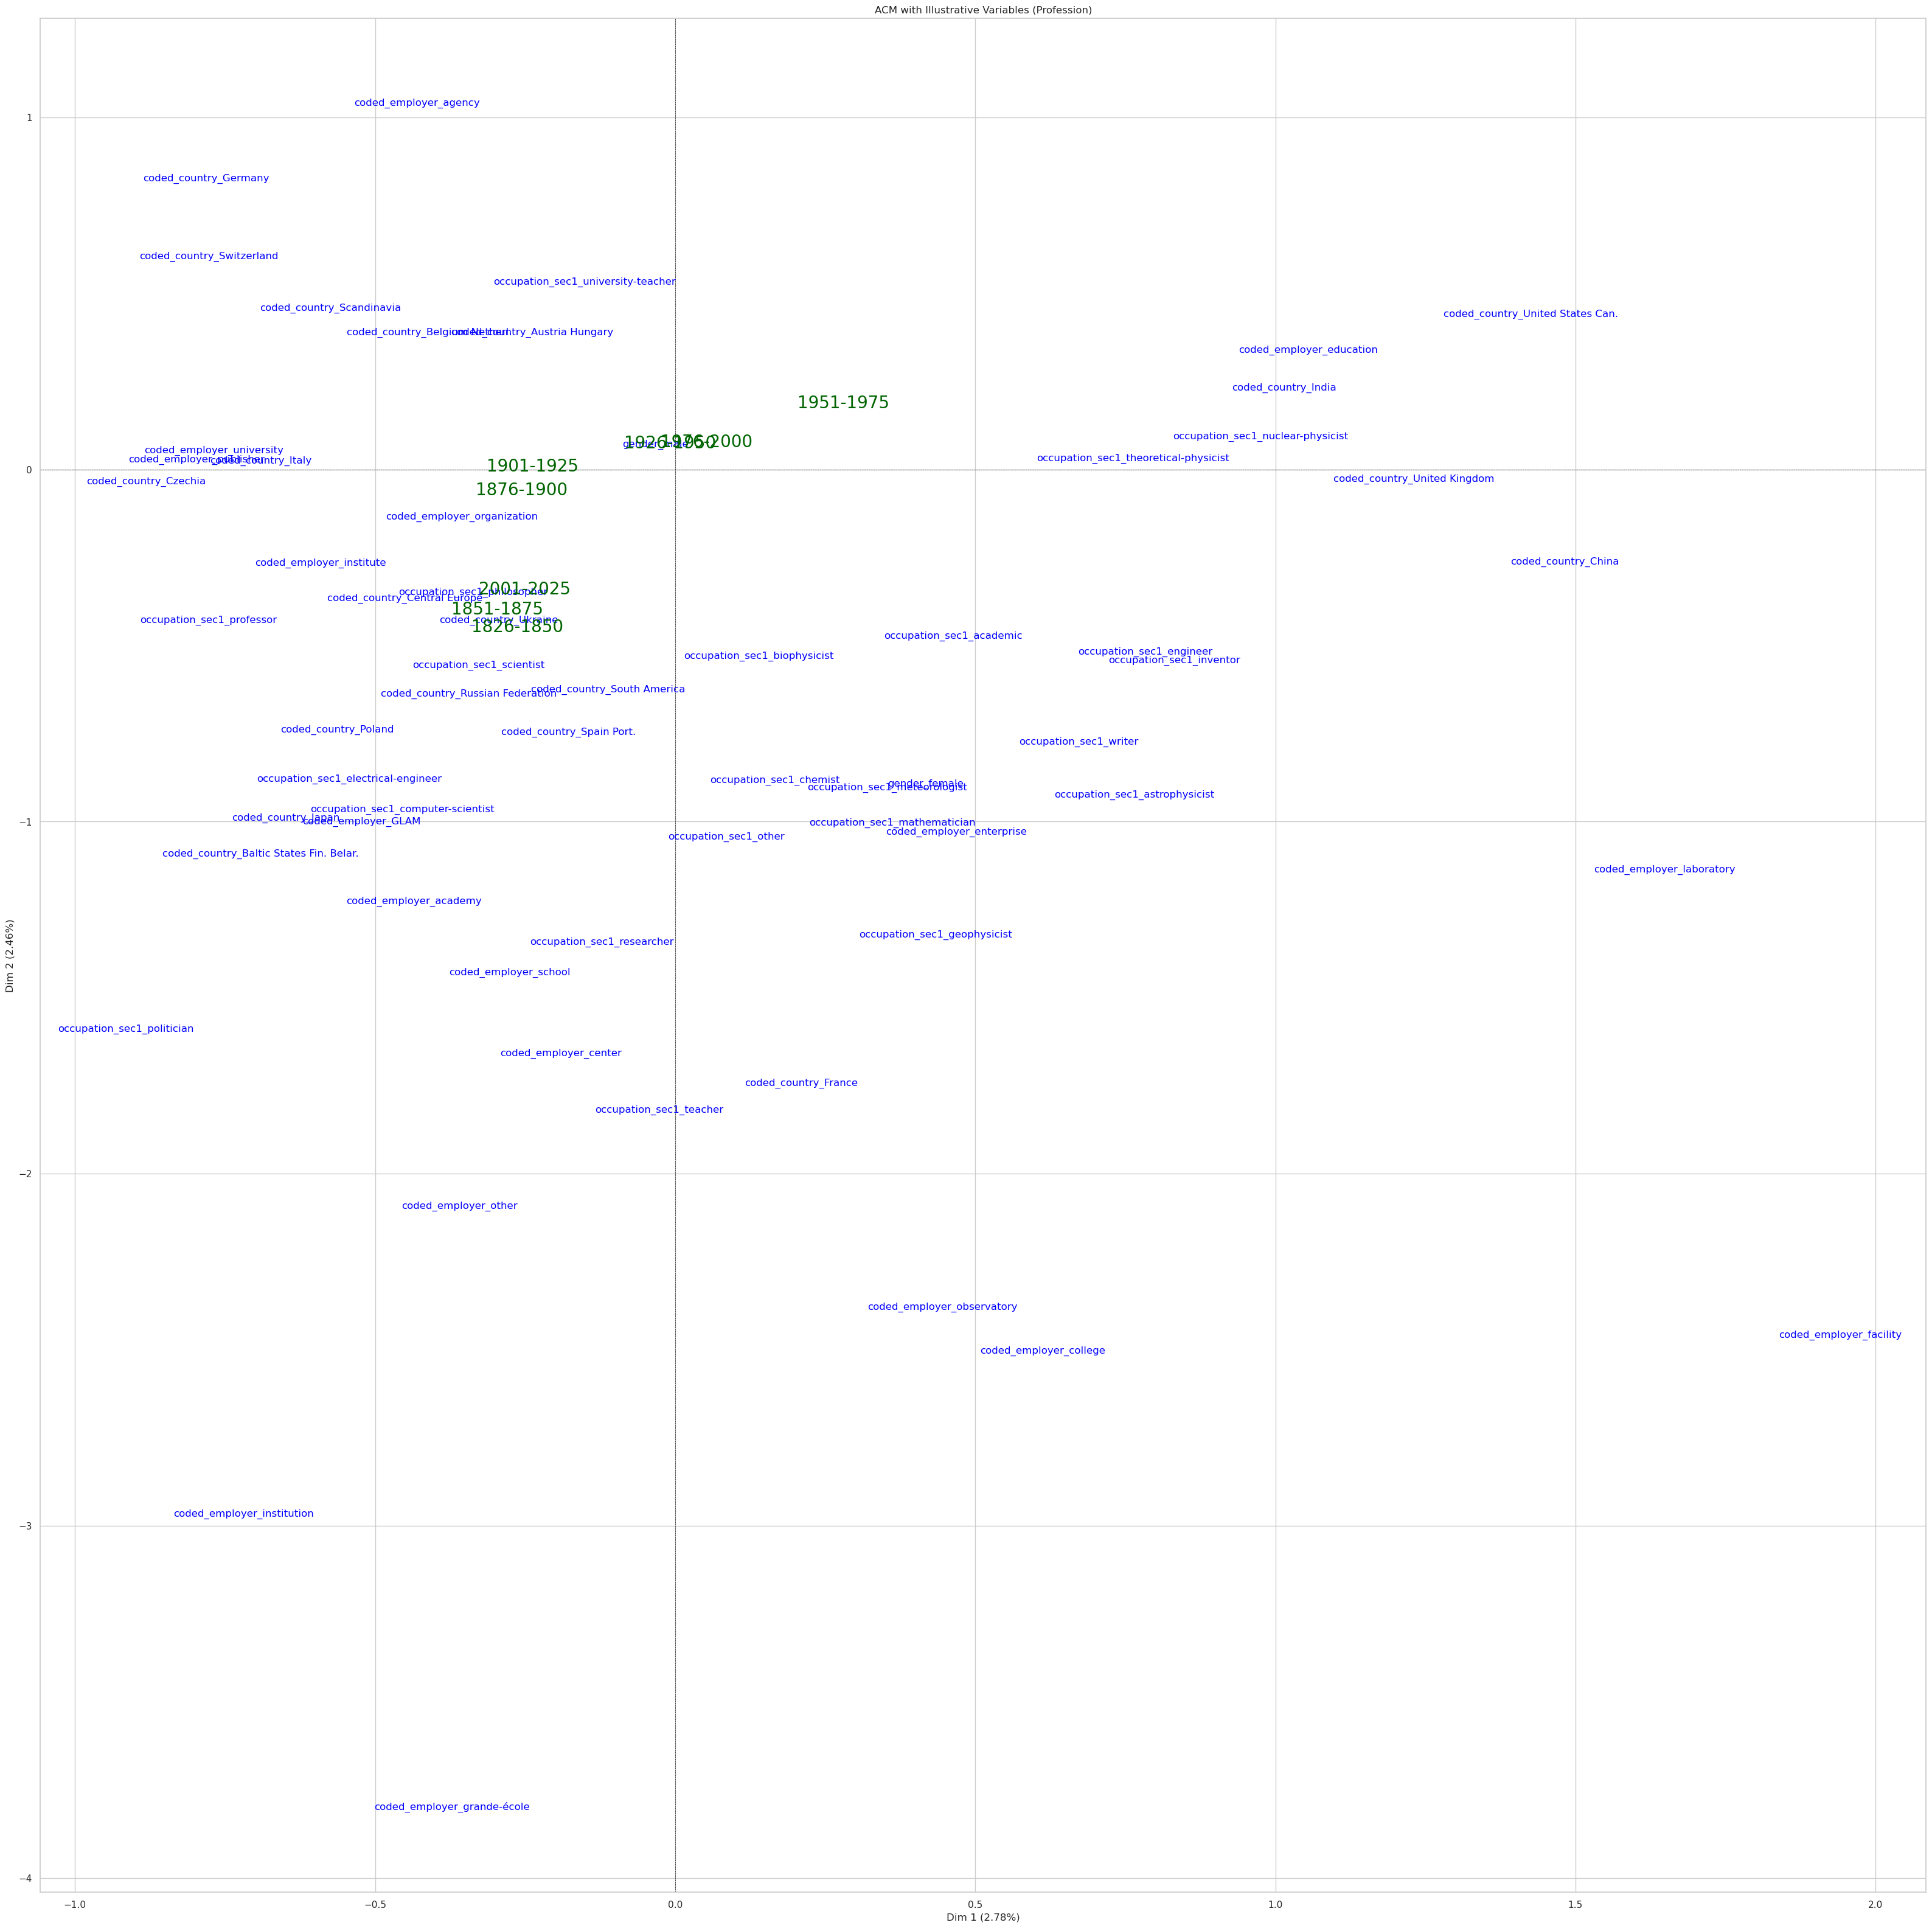

In [161]:


# Create your own figure and axes
fig, ax = plt.subplots(figsize=(40, 40))

# Plot ACM on ax
acm.mapping_col(num_x_axis=1, num_y_axis=2, ax=ax, short_labels=False)

# Add your additional layer

# Add illustrative variable modalities (e.g., Profession)
ax = plt.gca()  # Get current axis
for i in range(coord_fact.shape[0]):
    ax.text(coord_fact.iloc[i, 0], coord_fact.iloc[i, 1], coord_fact.index[i],
            color="darkgreen", fontsize=20, ha='center', va='center')

plt.title("ACM with Illustrative Variables (Profession)")
plt.show()


## Prepare file for cluster analysis

Given that the interpretation of the MCA is quite difficult, given the sparse nature of the variables, we will test the [K-means clustering method](da5-MCA-clusters.ipynb) on the results of the MCA in order to detect significant profiles.

We therefore export here the coded and prepared data to a [dedicated CSV file](da_data/da5-MCA-clusters.csv).

In [95]:
df_pm.head(3)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,REGION,NAME_ENGL,coded_country,periodsActivity,pk_person_features,occupation_main,occupation_sec1,coded_employer
0,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,POINT (6.578611 46.060278),Western Europe,France,France,1826-1850,27877,astronomer,mathematician,agency
1,http://www.wikidata.org/entity/Q4274939,Johann Ludwig Georg Meinecke,1781,male,Stadthagen,POINT (9.206944 52.324722),Western Europe,Germany,Germany,1826-1850,20217,physicist,chemist,university
2,http://www.wikidata.org/entity/Q5598801,Jonas Brag,1781,male,Göteborg City,POINT (11.965228 57.704581),Northern Europe,Sweden,Scandinavia,1826-1850,23593,astronomer,other,agency


In [96]:
file_address='da_data/da5-MCA-clusters.csv'
df_pm.to_csv(file_address, index=False)

## Split the generations and analyse significant ones

In [163]:
activity_period='1876-1900'
df_pm[df_pm.periodsActivity==activity_period].head(3)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,REGION,NAME_ENGL,coded_country,periodsActivity,pk_person_features,occupation_main,occupation_sec1,coded_employer
375,http://www.wikidata.org/entity/Q77029,Wilhelm Julius Foerster,1832,male,Zielona Góra,POINT (15.505 51.939722),Eastern Europe,Poland,Poland,1876-1900,28708,astronomer,university-teacher,publisher
376,http://www.wikidata.org/entity/Q125515,Henry Draper,1837,male,Prince Edward County,POINT (-78.44 37.22),Northern America,United States,United States Can.,1876-1900,7242,astronomer,other,education
377,http://www.wikidata.org/entity/Q1248435,George Frederick Barker,1835,male,Charlestown,POINT (-71.064444 42.375278),Northern America,United States,United States Can.,1876-1900,7129,physicist,chemist,education


## MCA

In [164]:
data_cat = df_pm[df_pm.periodsActivity==activity_period][['gender', 'coded_country', 'occupation_sec1', 'coded_employer']]
data_cat.head(3)


,gender,coded_country,occupation_sec1,coded_employer
375,male,Poland,university-teacher,publisher
376,male,United States Can.,other,education
377,male,United States Can.,chemist,education


In [165]:
DActives=data_cat

In [166]:
acm = MCA(row_labels=DActives.index,var_labels=DActives.columns)
acm.fit(DActives.values)

,n_components,None
,row_labels,"Index([375, 3...', length=351)"
,var_labels,Index(['gende...type='object')
,stats,True


In [167]:
eig = pd.DataFrame(acm.eig_).transpose()
eig.columns=['contribution','freq','freq_cumulee']

print('Number of factors (approximation tables):', len(eig), '\n')
print(eig.head(), eig.tail())


Number of factors (approximation tables): 47 

   contribution      freq  freq_cumulee
0      0.508944  4.331435      4.331435
1      0.461694  3.929309      8.260744
2      0.433218  3.686959     11.947703
3      0.422687  3.597339     15.545042
4      0.402811  3.428183     18.973225     contribution          freq  freq_cumulee
42  1.214365e-01  1.033502e+00     97.655105
43  1.072180e-01  9.124937e-01     98.567599
44  1.003475e-01  8.540210e-01     99.421620
45  6.795967e-02  5.783802e-01    100.000000
46  1.670423e-31  1.421637e-30    100.000000


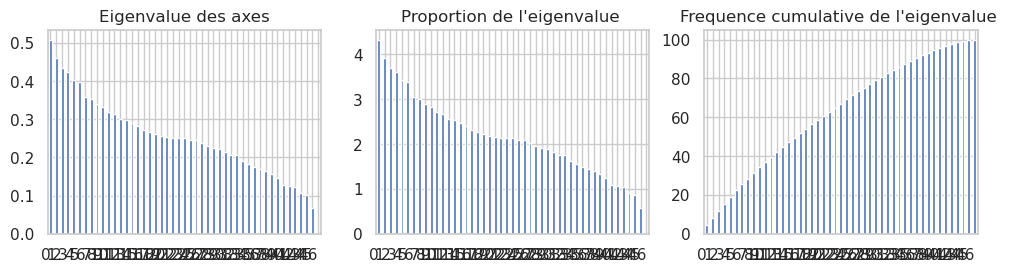

In [169]:

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12,3))

eig.iloc[:,0].plot(kind='bar', ax=axes[0], title='Eigenvalue des axes')
eig.iloc[:,1].plot(kind='bar', ax=axes[1], title="Proportion de l'eigenvalue ")
eig.iloc[:,2].plot(kind='bar', ax=axes[2], title="Frequence cumulative de l'eigenvalue ")
# Met les valeurs xticks en vertical
fig.autofmt_xdate(rotation=0)
plt.show()

<Axes: title={'center': 'Factor map for columns'}, xlabel='Dim 1 (4.33%)', ylabel='Dim 1 (4.33%)'>

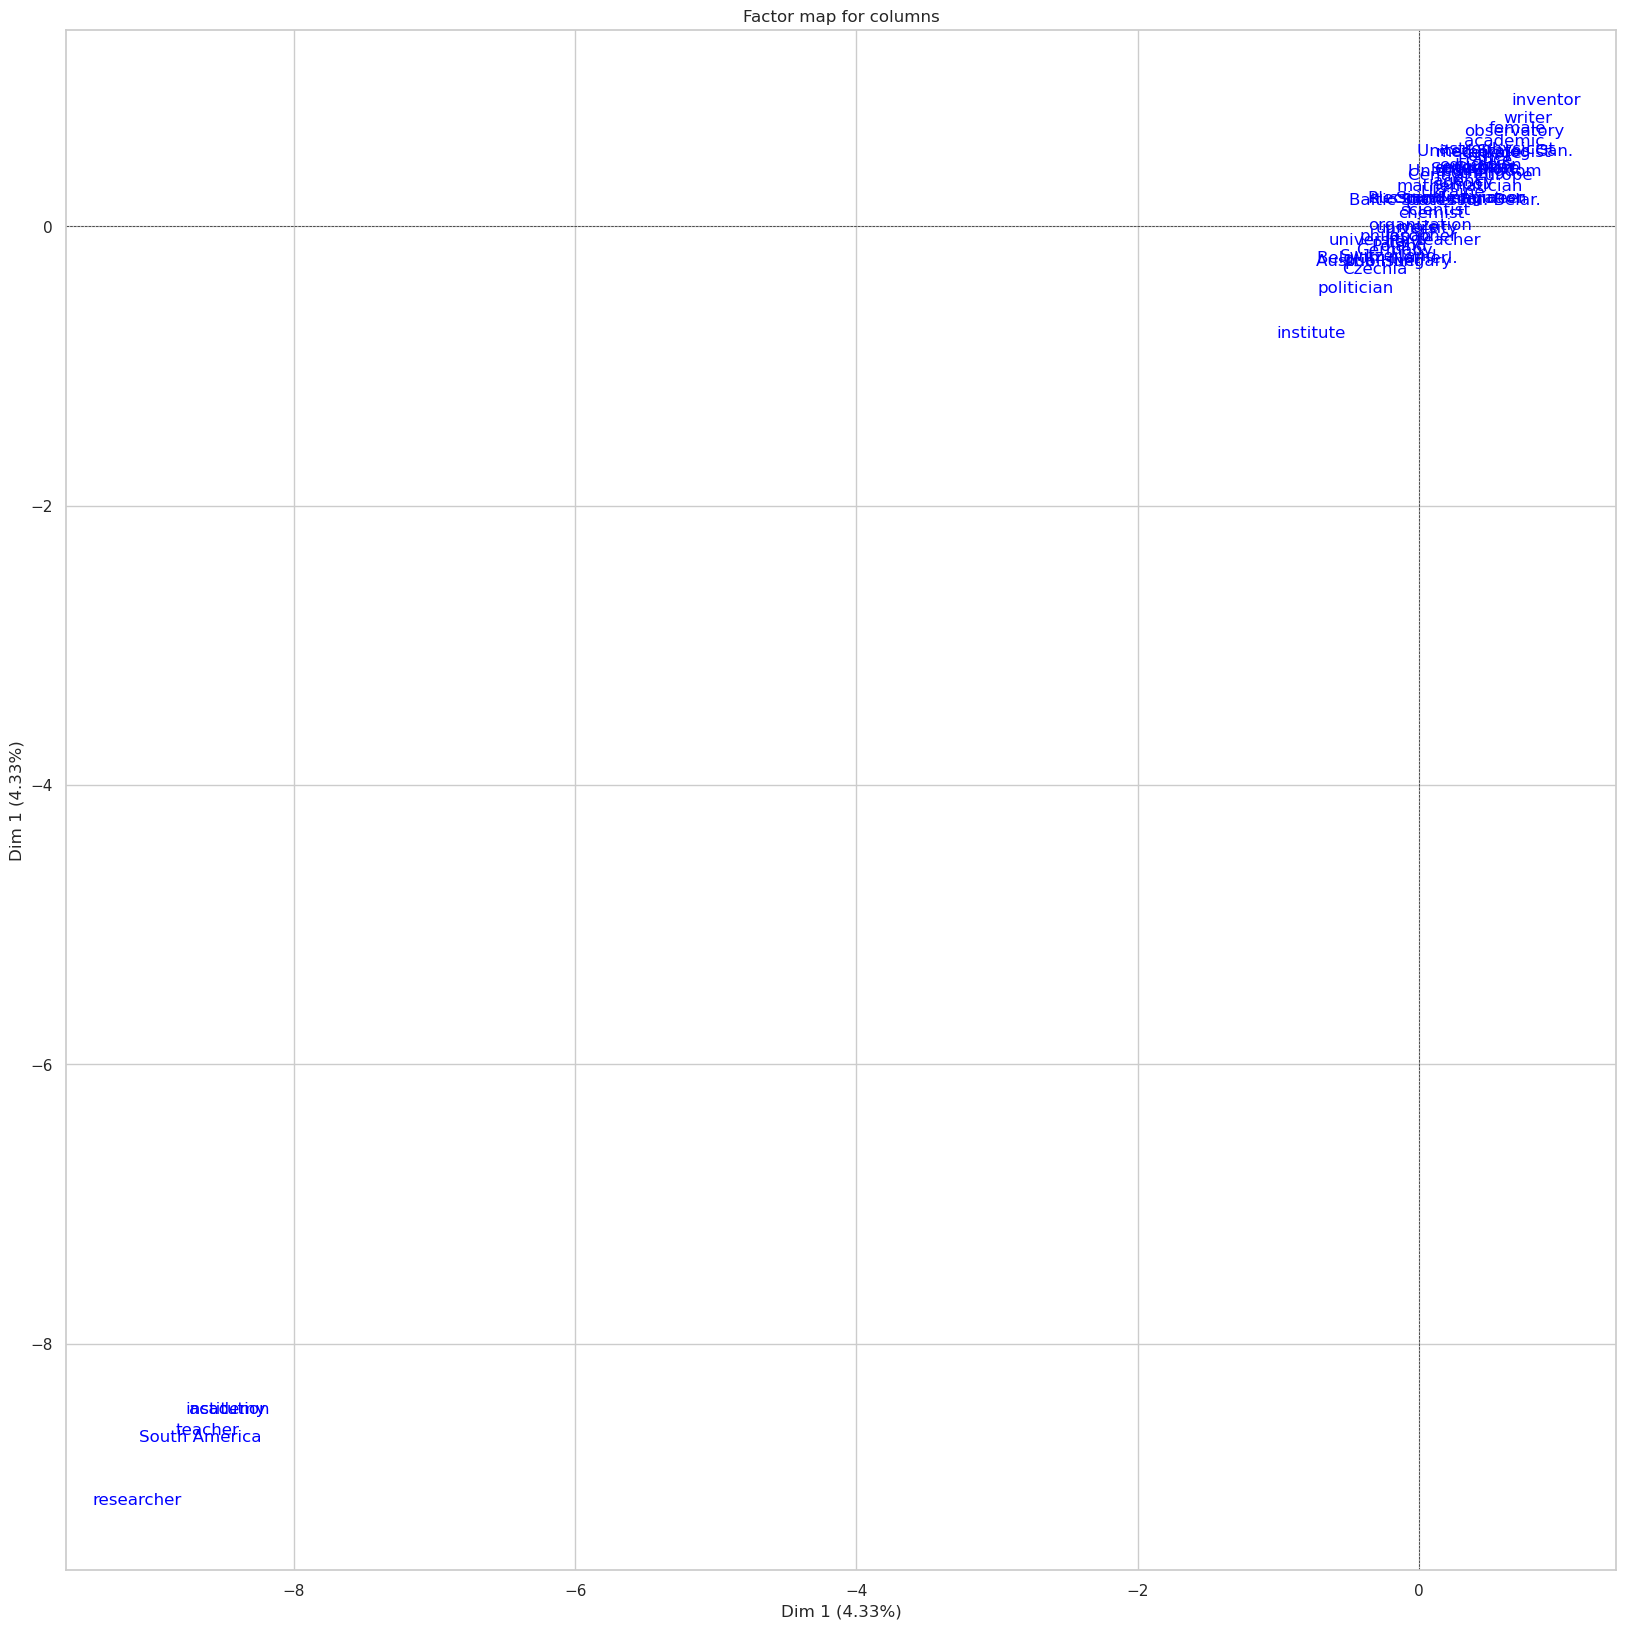

In [173]:
# Mapping des points colonnes
acm.mapping_col(num_x_axis=1, num_y_axis=1, figsize=(20,20))

## Représenter les individus

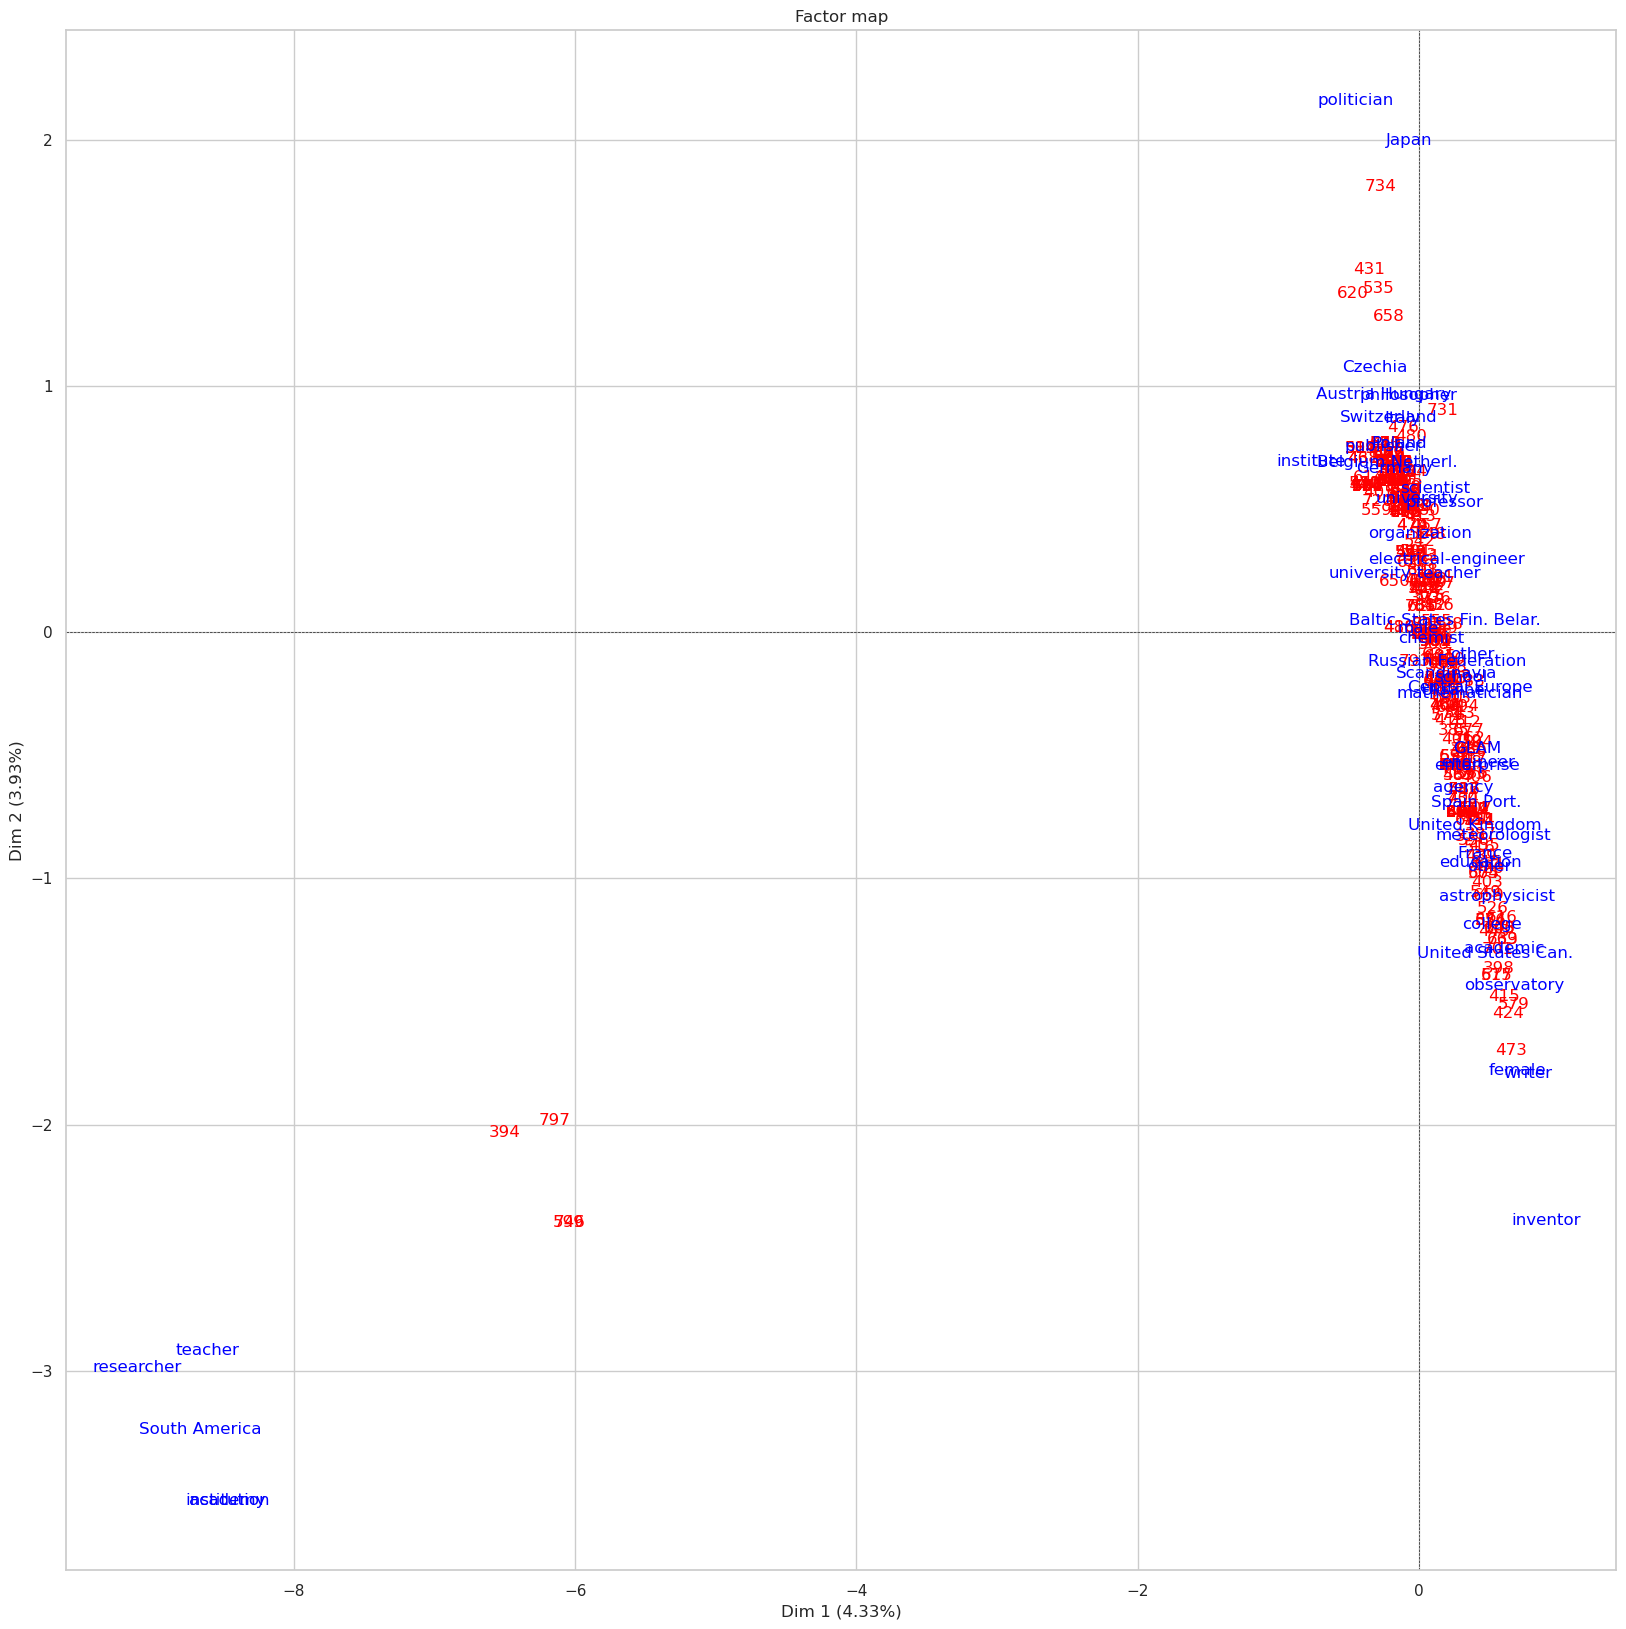

In [174]:
# Mapping simultané des points lignes et colonnes
# Les paramètres de la méthode mapping indiquent que ce sont les axes 1 et 2 qui sont ici représentés
acm.mapping(num_x_axis=1, num_y_axis=2, figsize=(20,20), )

In [175]:
### Inspect individuals
df_pm.loc[[394, 797, 424, 473]]

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,REGION,NAME_ENGL,coded_country,periodsActivity,pk_person_features,occupation_main,occupation_sec1,coded_employer
394,http://www.wikidata.org/entity/Q10324424,Manuel Pereira Reis,1837,male,Salvador,POINT (-38.492778 -12.983056),South America,Brazil,South America,1876-1900,763,astronomer,researcher,institute
797,http://www.wikidata.org/entity/Q24262108,Arturo Salazar,1855,male,Andacollo,POINT (-71.083333 -30.216667),South America,Chile,South America,1876-1900,15607,physicist,teacher,publisher
424,http://www.wikidata.org/entity/Q250936,Gaston Planté,1834,male,Orthez,POINT (-0.770833 43.488055),Western Europe,France,France,1876-1900,15879,physicist,inventor,education
473,http://www.wikidata.org/entity/Q3614641,Amos Dolbear,1837,male,Norwich,POINT (-72.0875 41.550278),Northern America,United States,United States Can.,1876-1900,18677,physicist,inventor,education
